# $n(z)$ forecast for 15 min exposure times

In [1]:
import numpy as np 
from astropy.table import Table, join

from astropy.cosmology import Planck18

# --- plotting ---
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

In [2]:
# (INSERT DOCUMENTATION ABOUT THIS CATALOG)
lam1d = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_s25a_matched_run21_run22.fits')
print('%i objects' % len(lam1d))

61684 objects


In [3]:
# cross-match to OII table from Jingjing's google drive 
oii = Table.read('/Users/hahnchanghoon/data/pfs/lam1d_oii_table_flux_sn_full_v2.fits')

lam1d = join(lam1d, oii['obj_id', 'oii_flux', 'oii sn2', 'oii noise', 'oii_sn pixel #'], keys=['obj_id'], join_type='left') 
mask_oii = lam1d['oii_flux'].mask 

In [4]:
# internal LAM 1D redshift quality cut
# only with good LAM 1D redshifts
lam_best = ((lam1d['probaGalaxy'] > 0.99) & 
           (lam1d['redshiftProba'] > 0.99) & 
           (lam1d['redshiftError'] < 0.01))
print('LAM-BEST %.3f' % np.mean(lam_best))

LAM-BEST 0.637


In [5]:
# compile HSC photometry
# extinction corrected magnitudes 
g_mag = lam1d['g_cmodel_mag'] - lam1d['a_g']
r_mag = lam1d['r_cmodel_mag'] - lam1d['a_r']
i_mag = lam1d['i_cmodel_mag'] - lam1d['a_i']
z_mag = lam1d['z_cmodel_mag'] - lam1d['a_z']

In [6]:
oii_snr = np.sqrt(lam1d['oii sn2']) / lam1d['oii_sn pixel #']

In [7]:
oii_snr_scaled = oii_snr / np.sqrt(lam1d['t_exp_total'] / 900.)

# color-magnitude cuts

In [8]:
rm_lowz = (((i_mag - z_mag) > 2 * (g_mag - r_mag) - 0.55) & #$(i-z) > 2 (g-r) - 0.55
           ((i_mag - z_mag) > -0.1))
print(np.mean(rm_lowz))

0.9357166018158236


In [9]:
# i-z color cut
iz_cut0 = (i_mag - z_mag) < 0.4
iz_cut1 = (i_mag - z_mag) < 0.25

In [10]:
diag_cut0 = (i_mag - z_mag) > 2 * (g_mag - r_mag) - 0.45

In [11]:
i23p8 = (i_mag < 23.8)
i23p6 = (i_mag < 23.6)

# $n(z)$ forecast

In [15]:
np.mean(~mask_oii)

np.float64(0.5005674080798911)

In [37]:
def f_assign(selection): 
    ''' estimated fiber assignment fraction 
    # 0.97 @ 6000 and 0.8 @ 3000
    '''
    Ntarget = 17000. * np.mean(selection)
    return np.clip((Ntarget - 3000.0)/17000. + 0.8, 0., 1.) 

def nz_lam(selection, zmin, zmax): 
    ''' Number of success redshifts for given selection per square degree --- based on LAM1D
    '''
    _zlim = (lam1d['redshift'] > zmin) & (lam1d['redshift'] < zmax) # redshift limit
    _fassign = f_assign(selection)
    
    Nz = 2900. / 1.25 * _fassign * (np.sum(selection & lam_best & _zlim) / np.sum(selection))
        
    # calculate comoving volume of 1 sq.deg
    _Vol = (1/41253. * (Planck18.comoving_volume(zmax) - Planck18.comoving_volume(zmin)) * Planck18.h**3).value
    return Nz / _Vol

def nz_lam_15min(selection, zmin, zmax, snr_cut=0.2): 
    ''' Number of success redshifts for given selection per square degree --- based on LAM1D
    '''
    _zlim = (lam1d['redshift'] > zmin) & (lam1d['redshift'] < zmax) # redshift limit
    _fassign = f_assign(selection)
    #print()
    #print((np.sum(selection & lam_best & _zlim)))
    #print((np.sum(selection & lam_best & _zlim & ~mask_oii & (np.log10(oii_snr_scaled) > 0.2))))
    
    Nz = 2900. / 1.25 * _fassign * 2 * (np.sum(selection & lam_best & _zlim & ~mask_oii & (np.log10(oii_snr_scaled) > 0.2)) / np.sum(selection))
        
    # calculate comoving volume of 1 sq.deg
    _Vol = (1/41253. * (Planck18.comoving_volume(zmax) - Planck18.comoving_volume(zmin)) * Planck18.h**3).value
    return Nz / _Vol    

In [38]:
zmid = [] 
ngs = np.zeros((7, 7))
ngs_15min = np.zeros((7, 7))
for i, zmin, zmax in zip(np.arange(7), [0.6, 0.8, 1., 1.2, 1.4, 1.6, 2.], [0.8, 1., 1.2, 1.4, 1.6, 2., 2.2]): 
    zmid.append(0.5*(zmin + zmax))    
    
    ngs[i, 0] = nz_lam(np.ones(len(lam1d)).astype(bool), zmin, zmax)
    ngs[i, 1] = nz_lam(rm_lowz, zmin, zmax)
    ngs[i, 2] = nz_lam(rm_lowz & iz_cut0, zmin, zmax)
    ngs[i, 3] = nz_lam(rm_lowz & iz_cut0 & i23p8, zmin, zmax)
    ngs[i, 4] = nz_lam(rm_lowz & iz_cut1 & i23p8, zmin, zmax)
    ngs[i, 5] = nz_lam(rm_lowz & iz_cut0 & i23p6, zmin, zmax)
    ngs[i, 6] = nz_lam(rm_lowz & iz_cut0 & diag_cut0 & i23p6, zmin, zmax)

    if zmin >= 1.6: continue
    ngs_15min[i, 0] = nz_lam_15min(np.ones(len(lam1d)).astype(bool), zmin, zmax)
    ngs_15min[i, 1] = nz_lam_15min(rm_lowz, zmin, zmax)
    ngs_15min[i, 2] = nz_lam_15min(rm_lowz & iz_cut0, zmin, zmax)
    ngs_15min[i, 3] = nz_lam_15min(rm_lowz & iz_cut0 & i23p8, zmin, zmax)
    ngs_15min[i, 4] = nz_lam_15min(rm_lowz & iz_cut1 & i23p8, zmin, zmax)
    ngs_15min[i, 5] = nz_lam_15min(rm_lowz & iz_cut0 & i23p6, zmin, zmax)
    ngs_15min[i, 6] = nz_lam_15min(rm_lowz & iz_cut0 & diag_cut0 & i23p6, zmin, zmax)

zmid = np.array(zmid)

/var/folders/w7/p2lcz8lj0m39n1ywl2_s0_j40000gp/T/ipykernel_59731/2289587457.py:29: RuntimeWarning: divide by zero encountered in log10
  Nz = 2900. / 1.25 * _fassign * 2 * (np.sum(selection & lam_best & _zlim & ~mask_oii & (np.log10(oii_snr_scaled) > 0.2)) / np.sum(selection))


(1e-06, 0.002)

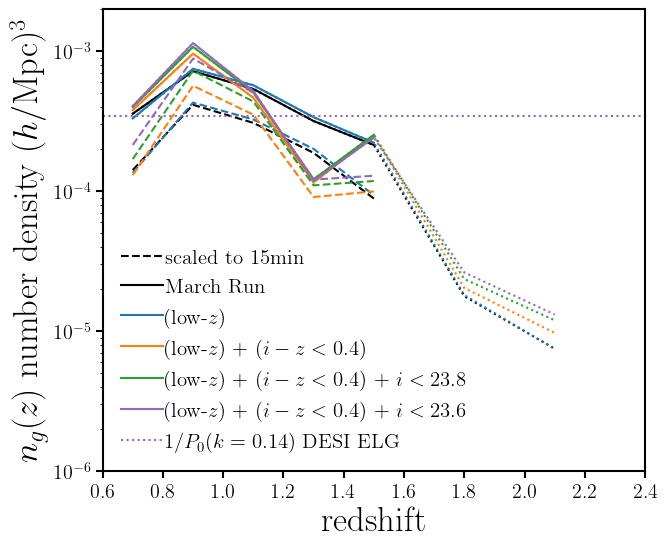

In [47]:
fig = plt.figure(figsize=(7,6))
sub = fig.add_subplot(111)


sub.plot([], [], c='k', ls='--', label='scaled to 15min')

# based on LAM)
sub.plot(zmid, ngs[:,0], color='k', ls=':')
sub.plot(zmid[zmid < 1.6], ngs[:,0][zmid < 1.6], color='k', label='March Run')
sub.plot(zmid[zmid < 1.6], ngs_15min[:,0][zmid < 1.6], color='k', ls='--')

sub.plot(zmid, ngs[:,1], color='C0', ls=':')
sub.plot(zmid[zmid < 1.6], ngs[:,1][zmid < 1.6], color='C0', label='(low-$z$)')
sub.plot(zmid[zmid < 1.6], ngs_15min[:,1][zmid < 1.6], color='C0', ls='--')

sub.plot(zmid, ngs[:,2], color='C1', ls=':')
sub.plot(zmid[zmid < 1.6], ngs[:,2][zmid < 1.6], color='C1', label='(low-$z$) + ($i-z < 0.4$)')
sub.plot(zmid[zmid < 1.6], ngs_15min[:,2][zmid < 1.6], color='C1', ls='--')

sub.plot(zmid, ngs[:,3], color='C2', ls=':')
sub.plot(zmid[zmid < 1.6], ngs[:,3][zmid < 1.6], color='C2', label='(low-$z$) + ($i-z < 0.4$) + $i < 23.8$')
sub.plot(zmid[zmid < 1.6], ngs_15min[:,3][zmid < 1.6], color='C2', ls='--')

# sub.plot(zmid, ngs[:,4], color='C3', ls=':')
# sub.plot(zmid[zmid < 1.6], ngs[:,4][zmid < 1.6], color='C3', label='(low-$z$) + ($i-z < 0.25$) + $i < 23.8$')
# sub.plot(zmid[zmid < 1.6], ngs_15min[:,4][zmid < 1.6], color='C3', ls='--')

sub.plot(zmid, ngs[:,5], color='C4', ls=':')
sub.plot(zmid[zmid < 1.6], ngs[:,5][zmid < 1.6], color='C4', label='(low-$z$) + ($i-z < 0.4$) + $i < 23.6$')
sub.plot(zmid[zmid < 1.6], ngs_15min[:,5][zmid < 1.6], color='C4', ls='--')

# sub.plot(zmid, ngs[:,6], color='C5', ls=':')
# sub.plot(zmid[zmid < 1.6], ngs[:,6][zmid < 1.6], color='C5', label='(low-$z$) + ($i-z < 0.4$) + diag. + $i < 23.6$')
# sub.plot(zmid[zmid < 1.6], ngs_15min[:,6][zmid < 1.6], color='C5', ls='--')


# reference n(z)
#sub.plot(ng_desi_elg[:,0], ng_desi_elg[:,1]*1e-4, c='k', ls=':', label='DESI ELG (Y1)')
#sub.plot(ng_desi_elg[:,0], 60/35.3*ng_desi_elg[:,1]*1e-4, c='k', ls='-.', label='DESI ELG (Y5)')
#sub.plot(invP0[:,0], invP0[:,1], c='r', ls=':', label='$1/P_g(k=0.1)$ PFS (T14)')

#sub.axhline(1.5e-4, c='r', ls='--', label='Recon. bias limit')
sub.axhline(1./(2.9e3), c='C4', ls=':', label=r'$1/P_0(k=0.14)$ DESI ELG')


sub.legend(loc='lower left', fontsize=15, handletextpad=0.1)
sub.set_xlabel('redshift', fontsize=25)
sub.set_xlim(0.6, 2.4)
sub.set_ylabel(r'$n_g(z)$ number density $(h/{\rm Mpc})^3$', fontsize=25)
sub.set_yscale('log')
sub.set_ylim(1e-6, 2e-3)
